In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [3]:
import PIL
from PIL import Image
import cv2

In [4]:
class ClothingClassifier(nn.Module):
    def __init__(self):
        super(ClothingClassifier, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1) #
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # Max-pooling layers
        self.pool = nn.MaxPool2d(2, 2) 
        # Fully connected layers
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)  # 10 classes for FashionMNIST

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) #32 x 14 x 14
        x = self.pool(F.relu(self.conv2(x))) #64 x 7 x 7
        # Flatten the tensor for fully connected layers
        x = x.view(-1, 64 * 7 * 7)
        
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [5]:
# Train model
model = ClothingClassifier()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  
criterion = nn.NLLLoss()

In [6]:
print(model)

ClothingClassifier(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [7]:

train_loader = DataLoader(datasets.FashionMNIST('./data', train=True, download=True,
                    transform=transforms.ToTensor()), batch_size=64, shuffle=True)
test_loader = DataLoader(datasets.FashionMNIST('./data', train=False, transform=transforms.ToTensor()), batch_size=64, shuffle=True)


In [8]:
train_loader.dataset.data[0].shape

torch.Size([28, 28])

In [10]:
num_epochs = 70
for epoch in range(num_epochs):
    for images, labels in train_loader:
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

In [11]:
torch.save(model.state_dict(), 'CNN_Model.pth')

In [12]:
model.load_state_dict(torch.load('CNN_Model.pth', map_location=torch.device('cpu')))

<All keys matched successfully>

In [13]:
model.eval()

ClothingClassifier(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [26]:
img = cv2.imread('images.jpeg', 0)

In [16]:
img.shape

(229, 220)

In [20]:
new_image = preprocess(img)

In [21]:
new_image.shape

torch.Size([1, 28, 28])

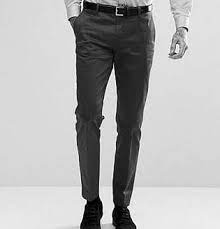

In [28]:
Image.fromarray(img)

In [22]:
predict(model, new_image)

[W NNPACK.cpp:64] Could not initialize NNPACK! Reason: Unsupported hardware.


7

In [23]:
test_loader.dataset.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [19]:
def preprocess(img):
    # Define a series of transformations
    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),  # Convert to grayscale (1 channel)
        transforms.Resize((28, 28)),  # Resize to 28x28 pixels
        transforms.ToTensor(),  # Convert to tensor
        transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize pixel values
    ])
    
    # Ensure the input is a PIL Image
    if not isinstance(img, Image.Image):
        img = Image.fromarray(img)
    
    # Apply the transformations
    img = transform(img)
    
    return img

In [18]:
# Preprocess function
def preprocess(img):
    transform = transforms.Compose([
    transforms.Resize(28),
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.5], std=[0.5])
    ])
    img = PIL.Image.fromarray(img)
    img = transform(img)
    return img 

# Prediction function
def predict(model, input):
    model.eval()
    with torch.no_grad():
        input = input.unsqueeze(0)
        output = model(input)
        pred = output.argmax(dim=1)
    return pred.item()

In [ ]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
import webcolors
from scipy.spatial import KDTree
from webcolors import CSS3_HEX_TO_NAMES, hex_to_rgb

def convert_rgb_to_names(rgb_tuple):
    
    # a dictionary of all the hex and their respective names in css3
    css3_db = CSS3_HEX_TO_NAMES
    names = []
    rgb_values = []
    for color_hex, color_name in css3_db.items():
        names.append(color_name)
        rgb_values.append(hex_to_rgb(color_hex))
    
    kdt_db = KDTree(rgb_values)
    distance, index = kdt_db.query(rgb_tuple)
    return f'closest match: {names[index]}'

def get_most_prominent_color(image_path, k=3):
    # Load the image
    image = cv2.imread(image_path)

    # Reshape the image to a 2D array of pixels
    pixels = image.reshape(-1, 3)

    # Perform K-Means clustering
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(pixels)

    # Get the cluster labels
    labels = kmeans.labels_

    # Count the number of pixels in each cluster
    unique, counts = np.unique(labels, return_counts=True)

    # Find the cluster with the most pixels
    most_prominent_cluster = unique[np.argmax(counts)]

    # Get the centroid (most prominent color)
    most_prominent_color = kmeans.cluster_centers_[most_prominent_cluster].astype(int)

    return most_prominent_color.tolist()

# Example usage:
image_path = 'images.jpeg'  # Replace with the path to your image
most_prominent_color = get_most_prominent_color(image_path)
print(f"Most Prominent Color (RGB): {tuple(most_prominent_color)}")
print(convert_rgb_to_names(tuple(most_prominent_color)))

In [1]:
with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(-1, 1, 28, 28)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

NameError: name 'torch' is not defined

Recommneder system

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
import json
data = {
    'user_ids': [1, 1, 2, 2, 3],
    'cloth_colors': ['red', 'blue', 'green', 'red', 'blue'],
    'cloth_types': ['shirt', 'pants', 'shirt', 'pants', 'shoes'],
}

import pandas as pd
df = pd.DataFrame(data)

df['cloth_features'] = df['cloth_types'] + ' ' + df['cloth_colors']

vectorizer = TfidfVectorizer()

cloth_matrix = vectorizer.fit_transform(df['cloth_features'])

cosine_sim = linear_kernel(cloth_matrix, cloth_matrix)

def get_cloth_recommendations(user_id, cloth_type, cloth_color, num_recommendations=2):
    input_cloth = cloth_type + ' ' + cloth_color

    input_cloth_vectorized = vectorizer.transform([input_cloth])

    similarity_scores = linear_kernel(input_cloth_vectorized, cloth_matrix).flatten()

    cloth_indices = similarity_scores.argsort()[::-1]

    user_liked_cloths = df[df['user_ids'] == user_id]['cloth_features'].tolist()
    cloth_indices = [idx for idx in cloth_indices if df['cloth_features'][idx] not in user_liked_cloths]

    top_recommendations = df.iloc[cloth_indices[:num_recommendations]][['cloth_types', 'cloth_colors']].values.tolist()

    return top_recommendations

user_id = 1
cloth_type = 'pants'
cloth_color = 'red'
recommendations = get_cloth_recommendations(user_id, cloth_type, cloth_color)
print(json.dumps(recommendations))
print(f"Top Cloth Recommendations for User {user_id} (Type: {cloth_type}, Color: {cloth_color}):")
for cloth_type, cloth_color in recommendations:
    print(f"Type: {cloth_type}, Color: {cloth_color}")

[["pants", "red"], ["shoes", "blue"]]
Top Cloth Recommendations for User 1 (Type: pants, Color: red):
Type: pants, Color: red
Type: shoes, Color: blue
